# Phase 3 / Day 2 — Activations, Forward Propagation & Loss

## Plotting ReLU, Sigmoid, Tanh

In [2]:
import numpy as np
import matplotlib.pyplot as plt

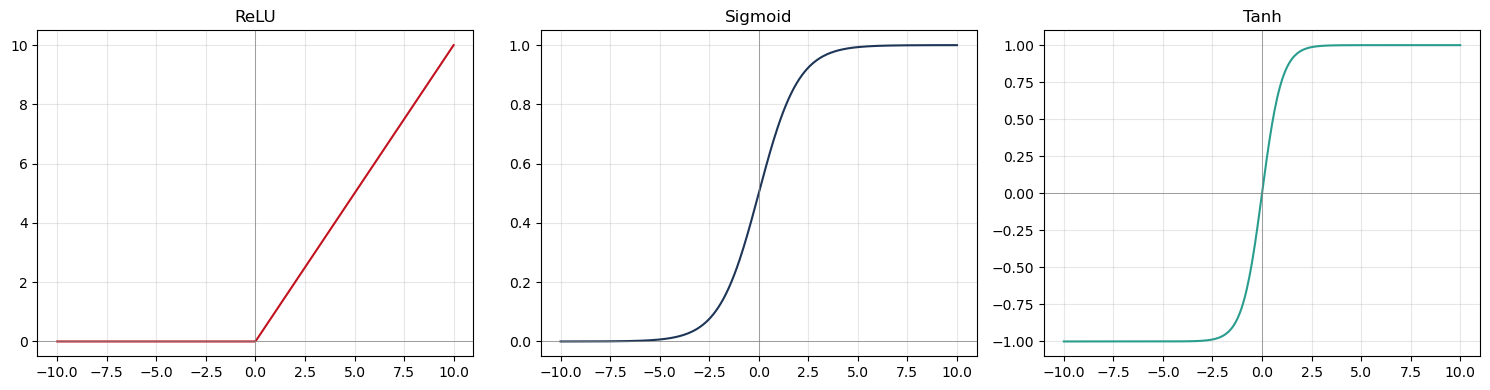

In [4]:
x = np.linspace(-10, 10, 300)

fig, axes = plt.subplots(1,3, figsize=(15,4))
activations = [
    ("ReLU", np.maximum(0,x), "#C1121F"),
    ("Sigmoid", 1 / (1 + np.exp(-x)), "#1D3557"),
    ("Tanh", np.tanh(x), "#2A9D8F")
]

for ax, (title, func, color) in zip(axes, activations):
    ax.plot(x, func, color=color)
    ax.set_title(title)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Ideal Output Activation & Loss Function for the Cardiac Project

*Given that cardiac project is a **Binary Classificationn task** (0/1)*

**Output activation: Sigmoid**, it maps any number to a value between 0 and 1 and because of using binary data it automatically gives you the predicted probability of having a heart disease without needing a second output node.

**Loss Function: Binary Cross-Entropy**, it directly measures the distance between the predicted probability and the true label and its gradient scales naturally with how confidently wrong a prediction is.

*Due to the class imbalance of the heart disease dataset, the calss_weight must be balanced to prevent the network from predicting the majority calss.*

## Forward Pass for a Tiny 2-layer Network on a Sample Input

In [7]:
k = np.array([0.5, -1.2, 0.8])

w1 = np.array([
    [0.2, -0.5, 0.1],
    [0.4, 0.3, -0.6]
])
b1 = np.array([0.1, -0.1])

w2 = np.array([[0.7, -0.3]])
b2 = np.array([0.05])

#layer 1  - ReLU
z1 = w1 @ k +b1
a1 = np.maximum(0,z1)

#layer 2  - Sigmoid
z2 = w2 @ a1 +b2
a2 = 1 / (1 +np.exp(-z2))

print("z1 - hidden pre-activation:", z1)
print("a1 - hidden post-ReLU:", a1)
print("z2 - output pre-activation:", z2)
print("a2 - final predicted probability:", a2)

z1 - hidden pre-activation: [ 0.88 -0.74]
a1 - hidden post-ReLU: [0.88 0.  ]
z2 - output pre-activation: [0.666]
a2 - final predicted probability: [0.66060691]


*A 2-layer network - 3-inputs, 2 hidden units with ReLU, 1 output with Sigmoid - was manually computed for sample input k.*

**Layer 1 - hidden Layer / ReLU:**
*Pre-activation:* z1 = [0.88 -0.74]
*Post-activation:* a1 = [0.88 0.00]

**Layer 2 - output Layer / Sigmoid:**
*Pre-activation:* z2 = [0.666]
*Final output:* a2 = [0.66060691]

Since the second hidden unit's contribution was zero, `z2` was effectively computed using the first hidden neuron's value (0.88), bias and weight, and the second hidden unit's weight `w2` was multiplied by 0.

**Interpretation:** The neural network's final output (0.661) would be read as *Predicted probability of 66.1% that `HeartDisease` = 1* for the used input. This is equivalent to *predicted_proba* from Logistic Regression/Random Forest baselines. However, bacuase of the arbitrary untrained weights, this number carries no real predictive meaning but only yhe mechanics of forward pass